<a href="https://colab.research.google.com/github/adnanmk-1999/Subpixel_Shift_CNN/blob/main/subpixel_shift_cnn_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Regression: Predict Subpixel Shift

In a *regression* problem, the aim is to predict the output of a continuous value, like a price or a probability. Contrast this with a *classification* problem, where the aim is to select a class from a list of classes.

This notebook trains a CNN to predict **subpixel-level X and Y shifts** directly from images. The ground truth shifts are embedded in each filename — for example:

- `test_1_81945_3_93417.png`  →  shift_x = **1.81945**,  shift_y = **3.93417**

We will follow the general machine learning workflow:
1. Examine and understand data
2. Build an input pipeline with `ImageDataGenerator`
3. Build our model
4. Train our model
5. Test our model

# Importing packages

In [73]:
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau

print(tf.__version__)

2.19.0


In [74]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split

# Make NumPy printouts easier to read.
np.set_printoptions(precision=3, suppress=True)

# Data Loading

Mount Google Drive and point to your image folders:
- `train_dir` — folder with your ~800 training images
- `val_dir`   — folder with your 100 dedicated validation images

In [75]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [76]:
train_dir = '/content/drive/MyDrive/Subpixel_Shift_CNN/train_dataset'
val_dir   = '/content/drive/MyDrive/Subpixel_Shift_CNN/val_dataset'
test_dir = '/content/drive/MyDrive/Subpixel_Shift_CNN/test_dataset'

# Check if the drive is mounted properly.

In [77]:
print(f"Checking path: {train_dir}")
if os.path.exists(train_dir):
    files = os.listdir(train_dir)
    print(f"Found {len(files)} total files in directory.")
    if len(files) > 0:
        print("First 5 files look like this:")
        print(files[:5])
else:
    print("WARNING: Directory does not exist. (Drive might not be mounted!)")

Checking path: /content/drive/MyDrive/Subpixel_Shift_CNN/train_dataset
Found 800 total files in directory.
First 5 files look like this:
['test_0.12915_1.22835.png', 'test_0.01597_0.16020.png', 'test_0.03372_2.81640.png', 'test_1.55044_0.90950.png', 'test_1.27176_2.90155.png']


### Understanding our data

The ground truth shift values are encoded directly in the filename:

`test_1_81945_3_93417.png`  →  `shift_x = 1.81945`,  `shift_y = 3.93417`

Let's parse all filenames and build a DataFrame.

In [78]:
def parse_filename(fname):
    """Extract (shift_x, shift_y) from a filename like test_0.12915_1.22835.png"""
    stem = Path(fname).stem

    m = re.match(r'^test_(-?\d+\.\d+)_(-?\d+\.\d+)$', stem)

    if m:
        sx, sy = m.groups()
        return float(sx), float(sy)

    return None, None

def load_labels_from_dir(directory):
    """Return a DataFrame with filepath, shift_x, shift_y for every PNG in directory."""
    records = []
    for fpath in sorted(Path(directory).glob('*.png')):
        sx, sy = parse_filename(fpath.name)
        if sx is not None:
            records.append({'filepath': str(fpath), 'shift_x': sx, 'shift_y': sy})
    return pd.DataFrame(records)

In [79]:
train_df = load_labels_from_dir(train_dir)
val_df   = load_labels_from_dir(val_dir)
test_df = load_labels_from_dir(test_dir)

total_train = len(train_df)
total_val   = len(val_df)
total_test  = len(test_df)

print('Total training images  :', total_train)
print('Total validation images:', total_val)
print('Total test images      :', total_test)

Total training images  : 800
Total validation images: 100
Total test images      : 100


In [80]:
train_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
shift_x,800.0,2.621467,1.408476,0.01597,1.449882,2.664835,3.832222,4.99739
shift_y,800.0,2.548603,1.501028,0.00123,1.240102,2.556070,3.861105,4.99975


# Setting Model Parameters

For convenience, set up variables that will be used while pre-processing our dataset and training our network.

In [81]:
BATCH_SIZE = 32
IMG_HEIGHT  = 300  # Our training data consists of images resized to IMG_SHAPE x IMG_SHAPE pixels
IMG_WIDTH = 363

# Data Augmentation

Overfitting often occurs when we have a small number of training examples. One way to fix this problem is to augment our dataset so that it has sufficient number and variety of training examples. `ImageDataGenerator` takes care of applying augmentations to the dataset during training.

**Important for this task:** because we are predicting spatial shifts, we must **not** apply spatial transforms such as flips, rotations, or translations — these would corrupt the ground truth labels. We only apply safe photometric augmentations.

In [82]:
# This function will plot images in the form of a grid with 1 row and 5 columns where images are placed in each column.
def plotImages(images_arr):
    fig, axes = plt.subplots(1, 5, figsize=(20, 20))
    axes = axes.flatten()
    for img, ax in zip(images_arr, axes):
        ax.imshow(img)
    plt.tight_layout()
    plt.show()

### Applying brightness augmentation

In [83]:
image_gen = ImageDataGenerator(rescale=1./255, brightness_range=[0.8, 1.2])

### Putting it all together

Here, we apply rescaling and brightness augmentation for training. For validation and test we only rescale — augmentation should never be applied to validation or test images.

In [84]:
image_gen_train = ImageDataGenerator(
    rescale=1./255,
    brightness_range=[0.85, 1.15],   # safe photometric augmentation only
)

image_gen_val = ImageDataGenerator(rescale=1./255)

### Custom data generator

Since our regression labels come from filenames rather than subfolder names, we write a simple `tf.keras.utils.Sequence` that uses `ImageDataGenerator` internally and yields continuous `[shift_x, shift_y]` labels.

In [85]:
class SubpixelDataGenerator(tf.keras.utils.Sequence):
    """Loads images using ImageDataGenerator and yields (images, [shift_x, shift_y]) batches."""

    def __init__(self, dataframe, image_data_generator, img_height, img_width, batch_size, shuffle=False):
        self.df             = dataframe.reset_index(drop=True)
        self.gen            = image_data_generator
        self.img_height     = img_height
        self.img_width      = img_width
        self.batch_size     = batch_size
        self.shuffle        = shuffle
        self.indexes        = np.arange(len(self.df))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indexes[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch     = self.df.iloc[batch_idx]

        images, labels = [], []
        for _, row in batch.iterrows():
            img = tf.keras.utils.load_img(
                row['filepath'], target_size=(self.img_height, self.img_width)
            )
            img = tf.keras.utils.img_to_array(img)
            img = self.gen.random_transform(img)   # apply augmentation
            img = self.gen.standardize(img)        # apply rescale=1./255
            images.append(img)
            labels.append([row['shift_x'], row['shift_y']])

        return np.array(images), np.array(labels, dtype=np.float32)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

In [86]:
train_data_gen = SubpixelDataGenerator(
    train_df, image_gen_train, IMG_HEIGHT, IMG_WIDTH, BATCH_SIZE, shuffle=True
)

val_data_gen = SubpixelDataGenerator(
    val_df, image_gen_val, IMG_HEIGHT, IMG_WIDTH, BATCH_SIZE, shuffle=False
)

test_data_gen = SubpixelDataGenerator(
    test_df, image_gen_val, IMG_HEIGHT, IMG_WIDTH, BATCH_SIZE, shuffle=False
)

Let's visualize a few training images to confirm the pipeline is working:

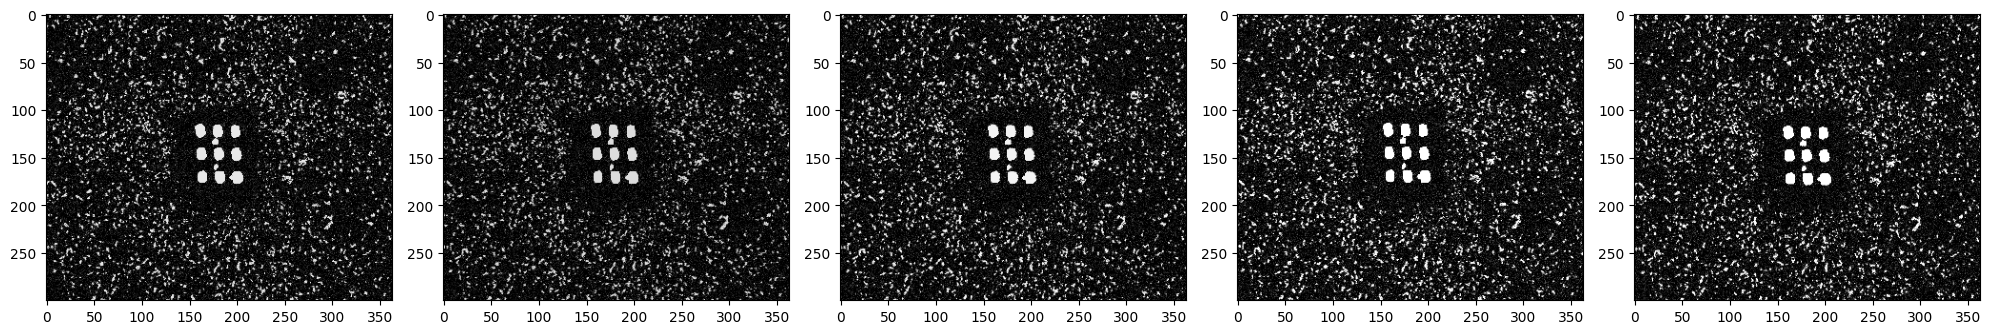

shift_x, shift_y for first 5 samples:
[[4.114 0.959]
 [2.635 1.057]
 [2.815 1.263]
 [0.665 0.012]
 [3.952 2.747]]


In [87]:
sample_images, sample_labels = train_data_gen[0]
plotImages(sample_images[:5])
print('shift_x, shift_y for first 5 samples:')
print(sample_labels[:5])

# Model Creation

## Define the model

The model consists of four convolution blocks with a max pool layer in each of them.

Before the final Dense layers, we apply a Dropout probability of 0.5 to prevent overfitting.

The output layer has **2 units with no activation** (linear) to produce continuous predictions for `shift_x` and `shift_y` — this is the standard setup for regression, as used in the fuel efficiency notebook.

In [88]:
model = tf.keras.models.Sequential([
    # Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    tf.keras.layers.MaxPooling2D(2, 2), # Back to Max Pooling!

    # Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Block 4
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Block 5 (NEW) - Shrinks the map safely so Flatten doesn't crash your RAM
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Dropout(0.5),

    # BACK TO FLATTEN! The model can now see exact spatial coordinates again.
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(2)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compiling the model

We use the `adam` optimizer. Since this is a regression problem we use `mean_absolute_error` as the loss function — the same loss used in the fuel efficiency regression notebook.

In [89]:
model.compile(optimizer='adam',
              loss='huber')

### Model Summary

Let's look at all the layers of our network using the `summary` method.

In [90]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 298, 361, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 149, 180, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 147, 178, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 73, 89, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 71, 87, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 35, 43, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 33, 41, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 7, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16128)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     8,258,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,795,074 (33.55 MB)

 Trainable params: 8,795,074 (33.55 MB)

 Non-trainable params: 0 (0.00 B)

# Create a Scheduler

In [91]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,       # Divide learning rate by 5
    patience=5,       # Wait 5 epochs before dropping
    min_lr=1e-6,      # Don't go lower than this
    verbose=1         # Print a message when it drops
)

### Train the model

In [92]:
epochs = 100
history_v2 = model.fit(
    train_data_gen,
    steps_per_epoch=int(np.ceil(total_train / float(BATCH_SIZE))),
    epochs=epochs,
    validation_data=val_data_gen,
    validation_steps=int(np.ceil(total_val / float(BATCH_SIZE))),
    callbacks=[lr_scheduler]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 403ms/step - loss: 1.5201 - val_loss: 0.8138 - learning_rate: 0.0010
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 323ms/step - loss: 0.8507 - val_loss: 0.9510 - learning_rate: 0.0010
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 357ms/step - loss: 0.8370 - val_loss: 0.7713 - learning_rate: 0.0010
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 298ms/step - loss: 0.7122 - val_loss: 0.4282 - learning_rate: 0.0010
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 319ms/step - loss: 0.3322 - val_loss: 0.0837 - learning_rate: 0.0010
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 353ms/step - loss: 0.1002 - val_loss: 0.0261 - learning_rate: 0.0010
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 342ms/step - loss: 0.0570 - val_loss: 0.0308 - learning_rate: 0.0010
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 329ms/step - loss: 0.0492 - val_loss: 0.0106 - learning_rate: 0.0010
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 338ms/step - loss: 0.0407 - val_loss: 0.0120 - learning_rate: 0.001

### Visualizing results of the training

In [93]:
def plot_loss(history):
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Error [pixels]')
    plt.legend()
    plt.grid(True)

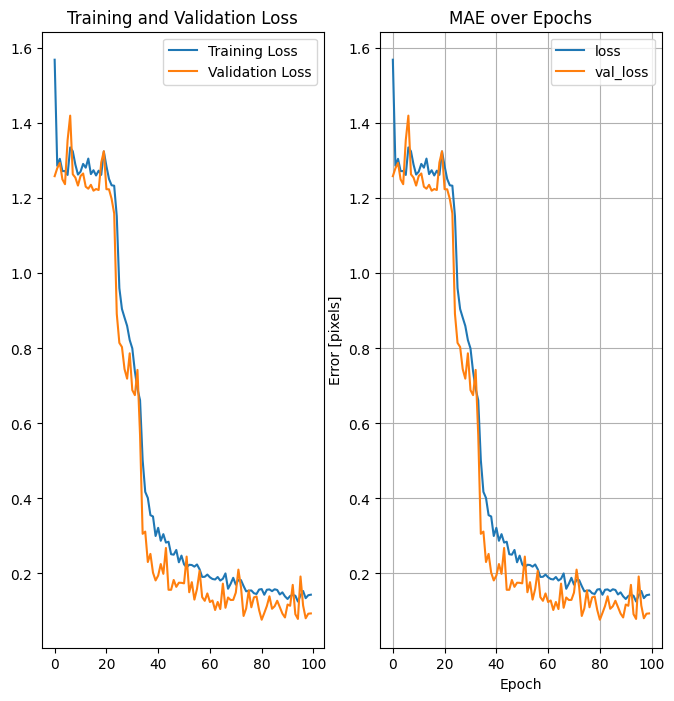

In [94]:
loss     = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plot_loss(history)
plt.title('MAE over Epochs')

plt.show()

# Performance

Collect the results on the test set:

In [95]:
test_results = {}

test_results['model'] = model.evaluate(
    test_data_gen,
    steps=int(np.ceil(total_test / float(BATCH_SIZE))),
    verbose=0
)

pd.DataFrame(test_results, index=['Mean absolute error [pixels]']).T

,Mean absolute error [pixels]
model,0.004396


### Make predictions

You can now make predictions with the model on the test set using `Model.predict` and review the loss:

In [96]:
test_predictions = model.predict(
    test_data_gen,
    steps=int(np.ceil(total_test / float(BATCH_SIZE)))
)

# Collect true labels in the same order as the generator
test_labels = test_df[['shift_x', 'shift_y']].values
test_predictions = test_predictions[:len(test_labels)]

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 317ms/step


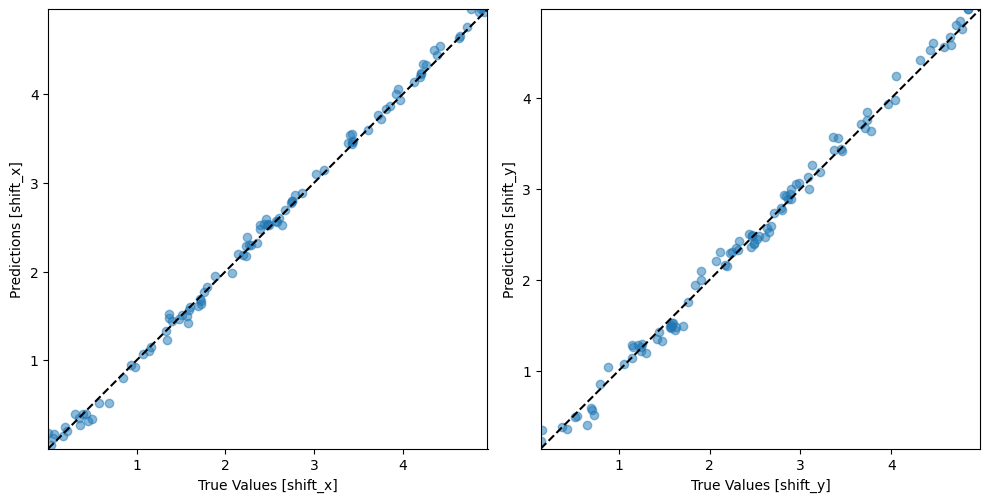

In [97]:
# Scatter plot: predicted vs. true for shift_x and shift_y
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i, label in enumerate(['shift_x', 'shift_y']):
    a = axes[i]
    a.set_aspect('equal')
    a.scatter(test_labels[:, i], test_predictions[:, i], alpha=0.5)
    lims = [test_labels[:, i].min(), test_labels[:, i].max()]
    a.set_xlim(lims)
    a.set_ylim(lims)
    a.plot(lims, lims, 'k--')
    a.set_xlabel(f'True Values [{label}]')
    a.set_ylabel(f'Predictions [{label}]')

plt.tight_layout()
plt.show()

Now, check the error distribution:

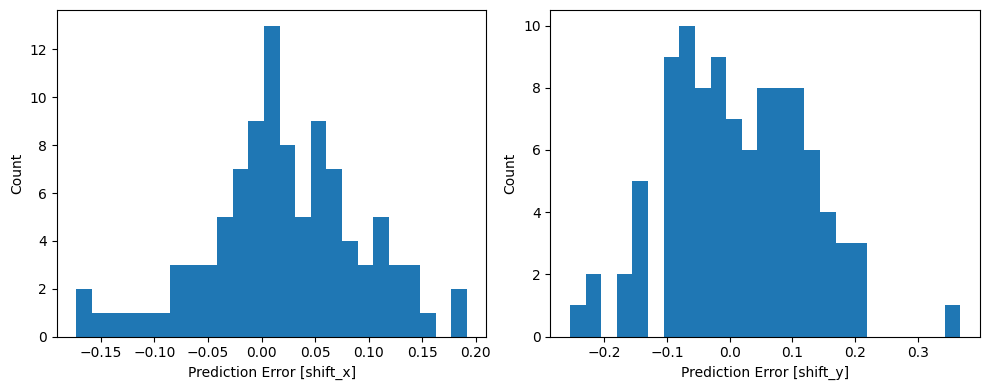

MAE shift_x : 0.05831 pixels
MAE shift_y : 0.08865 pixels


In [98]:
error_x = test_predictions[:, 0] - test_labels[:, 0]
error_y = test_predictions[:, 1] - test_labels[:, 1]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(error_x, bins=25)
plt.xlabel('Prediction Error [shift_x]')
_ = plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(error_y, bins=25)
plt.xlabel('Prediction Error [shift_y]')
_ = plt.ylabel('Count')

plt.tight_layout()
plt.show()

print(f'MAE shift_x : {np.mean(np.abs(error_x)):.5f} pixels')
print(f'MAE shift_y : {np.mean(np.abs(error_y)):.5f} pixels')

If you're happy with the model, save it for later use with `Model.save`:

In [99]:
model.save('subpixel_shift_model.keras')
model.save('/content/drive/MyDrive/Subpixel_Shift_CNN/subpixel_shift_model.keras')

If you reload the model, it gives identical output:

In [100]:
reloaded = tf.keras.models.load_model('subpixel_shift_model.keras')

test_results['reloaded'] = reloaded.evaluate(
    test_data_gen,
    steps=int(np.ceil(total_test / float(BATCH_SIZE))),
    verbose=0
)

pd.DataFrame(test_results, index=['Mean absolute error [pixels]']).T

,Mean absolute error [pixels]
model,0.004396
reloaded,0.004396


**Test Model with Random Image from the Test Dataset**

--- PREDICTION RESULTS ---
File: test_3.38071_2.19254.png
True X Shift : 3.38071
Pred X Shift : 3.45313
-> X Error   : 0.07242 pixels

True Y Shift : 2.19254
Pred Y Shift : 2.15660
-> Y Error   : 0.03594 pixels


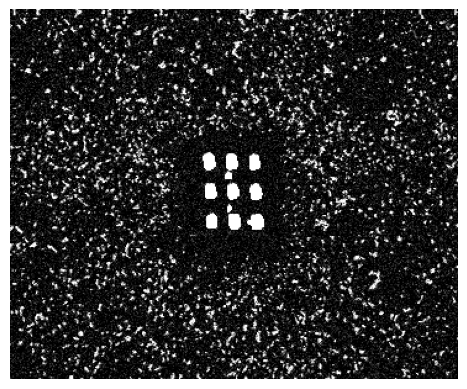

In [106]:
# 1. Grab one random row from your test dataframe
random_sample = test_df.sample(n=1).iloc[0]

img_path = random_sample['filepath']
true_x = random_sample['shift_x']
true_y = random_sample['shift_y']

# 2. Load and preprocess the image
# We use the IMG_HEIGHT (300) and IMG_WIDTH (363) you set earlier
img = tf.keras.utils.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_array = tf.keras.utils.img_to_array(img)
img_array = img_array / 255.0  # Crucial: apply the 1./255 scaling!

# 3. Add a "batch" dimension
# Keras models ALWAYS expect a batch. We change shape from (300, 363, 3) to (1, 300, 363, 3)
img_batch = np.expand_dims(img_array, axis=0)

# 4. Make the prediction!
prediction = model.predict(img_batch, verbose=0)
pred_x, pred_y = prediction[0]

# 5. Print the results
print("--- PREDICTION RESULTS ---")
print(f"File: {img_path.split('/')[-1]}")
print(f"True X Shift : {true_x:.5f}")
print(f"Pred X Shift : {pred_x:.5f}")
print(f"-> X Error   : {abs(true_x - pred_x):.5f} pixels\n")

print(f"True Y Shift : {true_y:.5f}")
print(f"Pred Y Shift : {pred_y:.5f}")
print(f"-> Y Error   : {abs(true_y - pred_y):.5f} pixels")

# Optional: Show the image just so you know what you're looking at
plt.imshow(img)
plt.axis('off')
plt.show()

## Conclusion

This notebook introduced a few techniques to handle a CNN regression problem. Here are a few more tips that may help:

- Mean absolute error (MAE) is the standard loss for regression problems. It is less sensitive to outliers than MSE.
- The CNN architecture follows the Dogs vs Cats structure exactly (4× Conv+MaxPool blocks), with the final `softmax` classification layer replaced by a linear `Dense(2)` output — one value for `shift_x` and one for `shift_y`.
- Data augmentation was restricted to **photometric only** (brightness, very mild zoom). Spatial transforms like flips and rotations are unsafe for this task as they would change the true shift values.
- The dedicated 100-image validation set is passed directly as `validation_data` to monitor overfitting throughout training — no random splitting needed.